# (27) poisson: increase inner lr

project = ```iP-VAE```, host = ```yoru```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Load

In [3]:
a = 'poisson_vH16-wht_t-16_b-24_k-[512]_u-10,du-10'
b = 'gold-standard_b200-ep300-lr(0.005)_temp(0.01:0.5)_gr(300)_(2025_04_22,18:28)'

tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

300

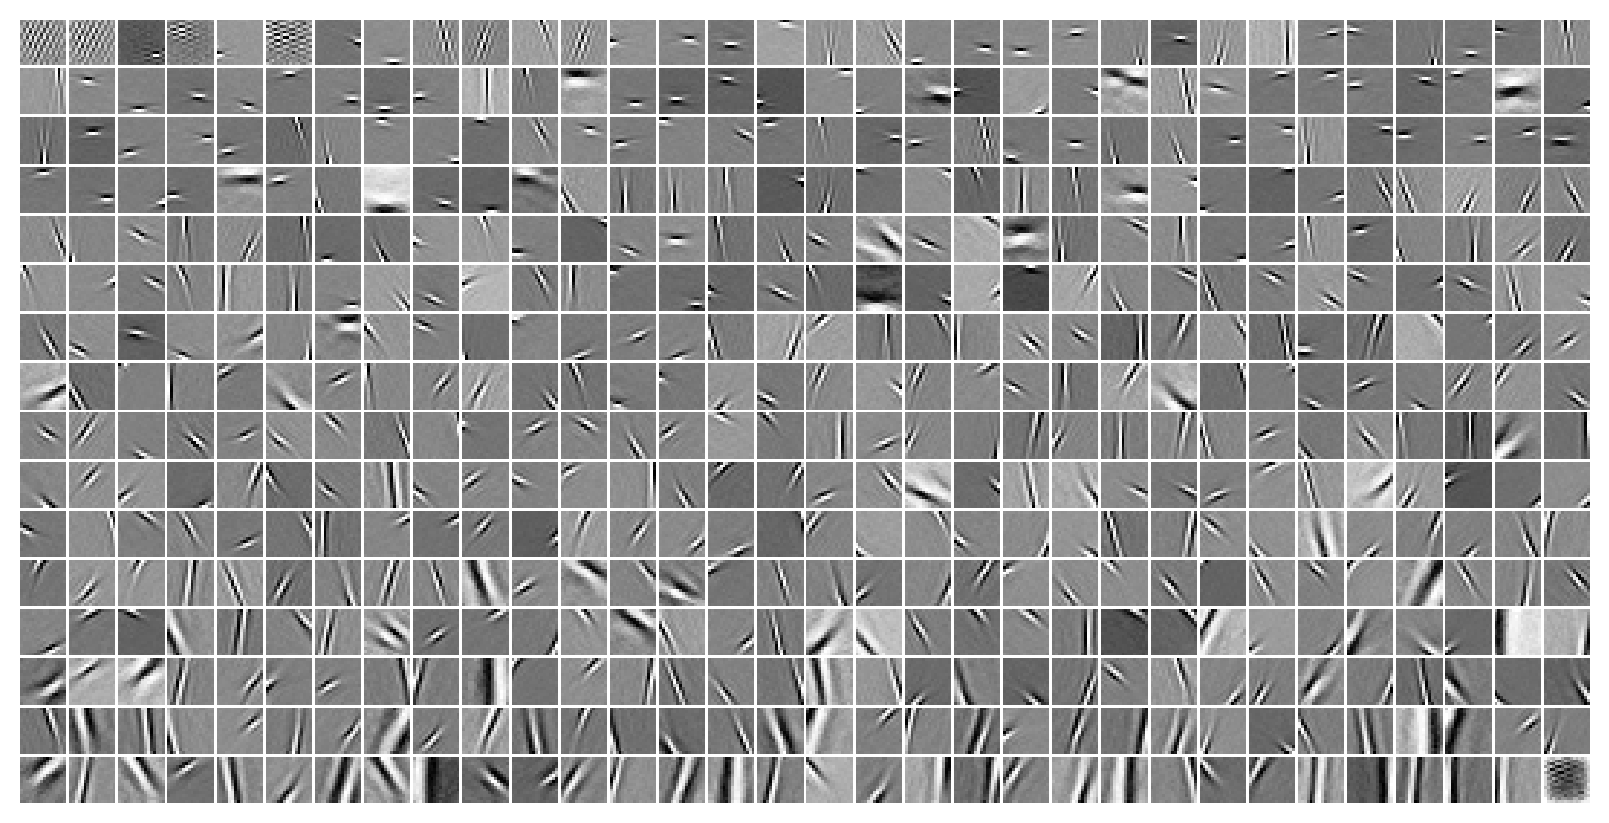

In [4]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

## Establish actual

In [5]:
print(tr.model.layer.log_lr[0].exp())

tensor([0.1762], device='cuda:0', grad_fn=<ExpBackward0>)

100%|███████████████████████████████████| 1/1 [00:11<00:00, 11.33s/it]


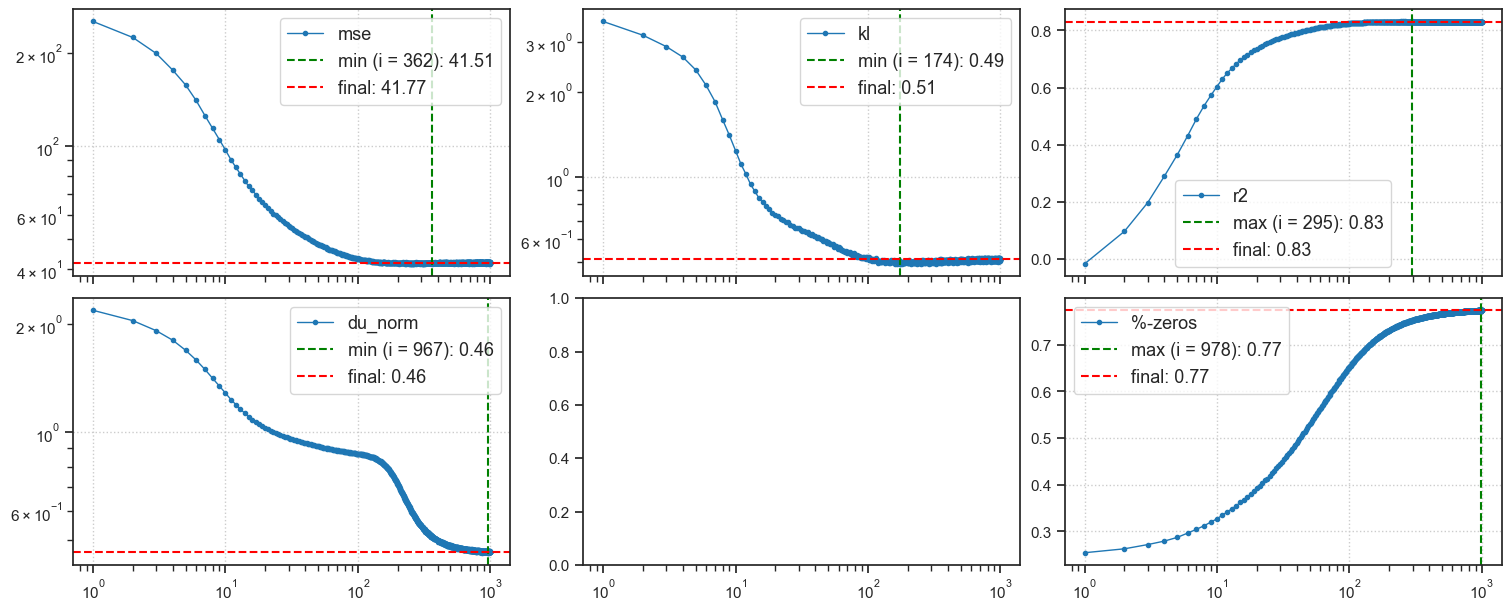

In [6]:
kws_analysis = dict(
    t_total=1000,
    data_batch_sz=2000,
    n_data_batches=1,
)
results = tr.analysis('vld', **kws_analysis)
_ = plot_convergence(results)

## Increase inner lr

In [7]:
original_lr = tr.model.layer.log_lr[0].exp().item()

### 2x 

In [8]:
new_lr = original_lr * 2

In [9]:
print(f"original_lr:\t{original_lr}\nnew_lr:\t\t{new_lr}")

original_lr:    0.17621681094169617
new_lr:         0.35243362188339233

In [10]:
tr.model.layer.log_lr[0].data.fill_(np.log(new_lr))
print(tr.model.layer.log_lr[0].exp())

tensor([0.3524], device='cuda:0', grad_fn=<ExpBackward0>)

100%|███████████████████████████████████| 1/1 [00:10<00:00, 10.76s/it]


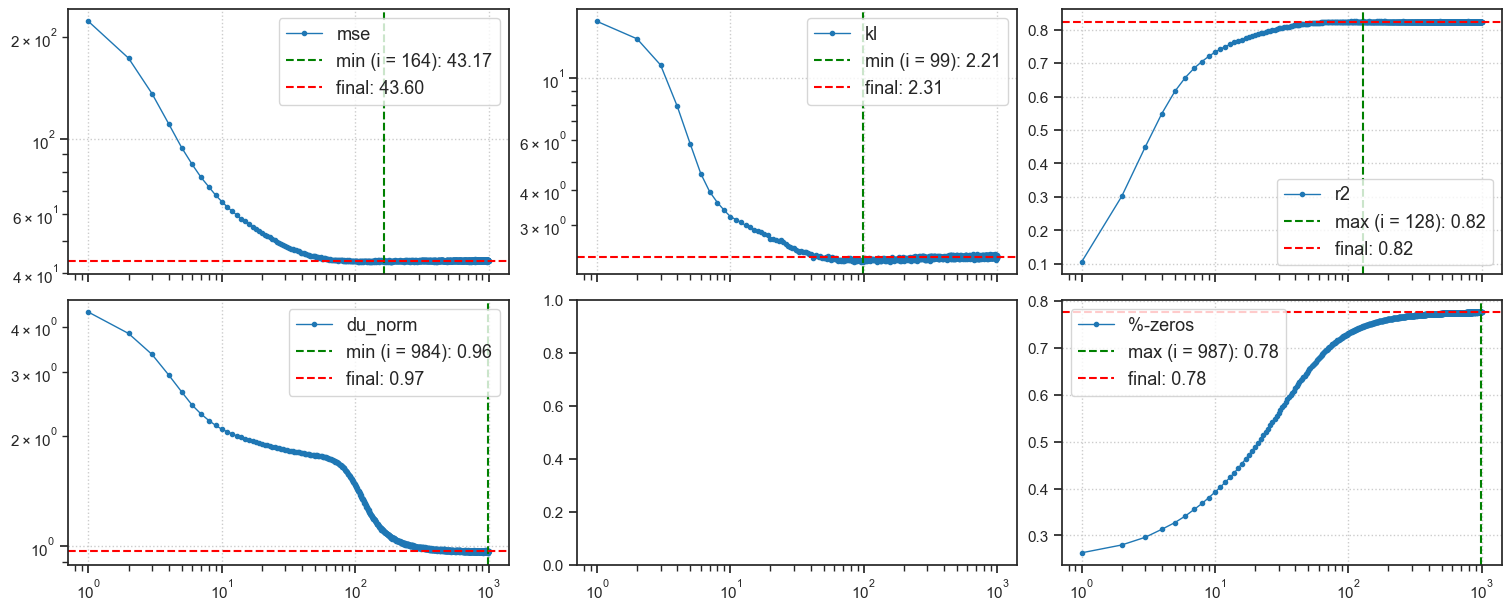

In [11]:
results_2x = tr.analysis('vld', **kws_analysis)
_ = plot_convergence(results_2x)

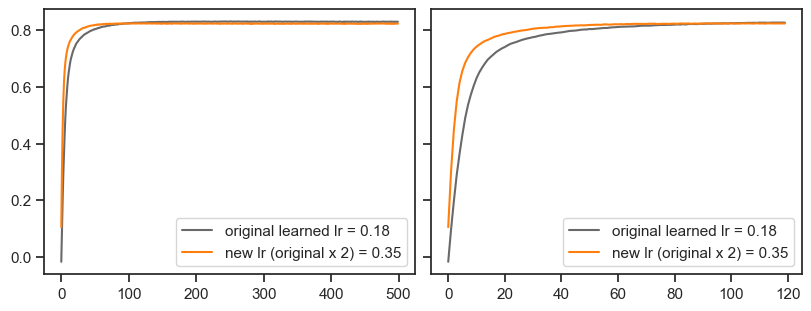

In [12]:
fig, axes = create_figure(1, 2, (8, 3), sharey='all')

for ax, num_t in zip(axes, [500, 120]):
    ax.plot(results['r2'][:num_t], color='dimgrey', label=f"original learned lr = {original_lr:0.2f}")
    ax.plot(results_2x['r2'][:num_t], color='C1', label=f"new lr (original x 2) = {new_lr:0.2f}")

add_legend(axes)
plt.show()

### 3x 

In [17]:
new_lr = original_lr * 3

In [18]:
print(f"original_lr:\t{original_lr}\nnew_lr:\t\t{new_lr}")

original_lr:    0.17621681094169617
new_lr:         0.5286504328250885

In [19]:
tr.model.layer.log_lr[0].data.fill_(np.log(new_lr))
print(tr.model.layer.log_lr[0].exp())

tensor([0.5287], device='cuda:0', grad_fn=<ExpBackward0>)

100%|███████████████████████████████████| 1/1 [00:10<00:00, 10.78s/it]


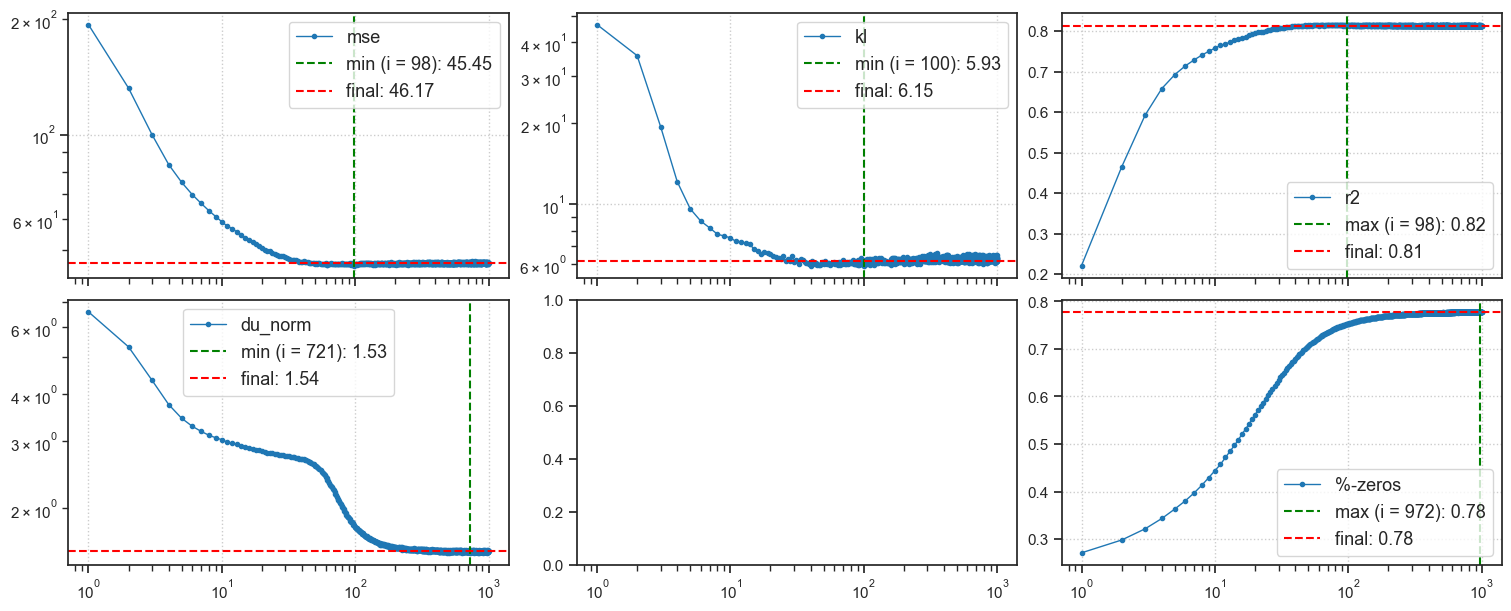

In [20]:
results_3x = tr.analysis('vld', **kws_analysis)
_ = plot_convergence(results_3x)

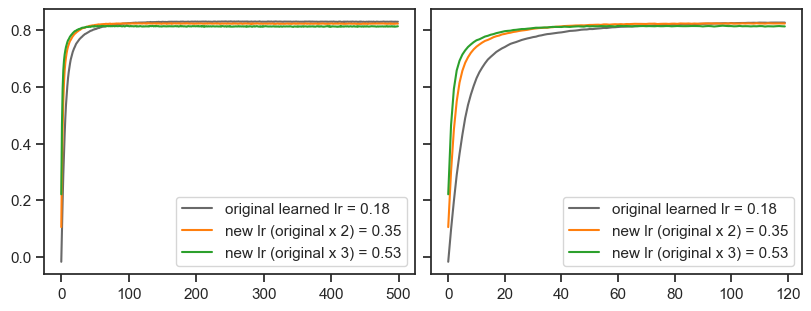

In [24]:
fig, axes = create_figure(1, 2, (8, 3), sharey='all')

for ax, num_t in zip(axes, [500, 120]):
    ax.plot(results['r2'][:num_t], color='dimgrey', label=f"original learned lr = {original_lr:0.2f}")
    ax.plot(results_2x['r2'][:num_t], color='C1', label=f"new lr (original x 2) = {original_lr * 2:0.2f}")
    ax.plot(results_3x['r2'][:num_t], color='C2', label=f"new lr (original x 3) = {original_lr * 3:0.2f}")

add_legend(axes)
plt.show()

### 4x 

In [25]:
new_lr = original_lr * 4

In [26]:
print(f"original_lr:\t{original_lr}\nnew_lr:\t\t{new_lr}")

original_lr:    0.17621681094169617
new_lr:         0.7048672437667847

In [27]:
tr.model.layer.log_lr[0].data.fill_(np.log(new_lr))
print(tr.model.layer.log_lr[0].exp())

tensor([0.7049], device='cuda:0', grad_fn=<ExpBackward0>)

100%|███████████████████████████████████| 1/1 [00:10<00:00, 10.96s/it]


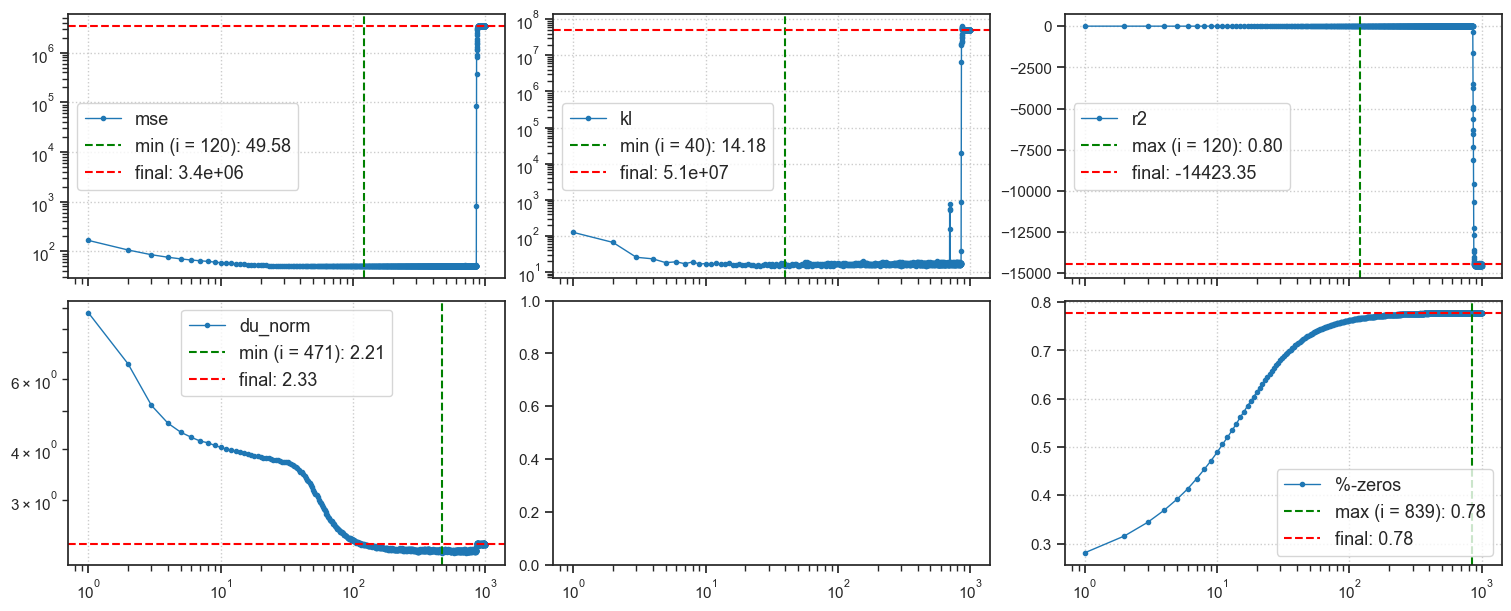

In [28]:
results_4x = tr.analysis('vld', **kws_analysis)
_ = plot_convergence(results_4x)

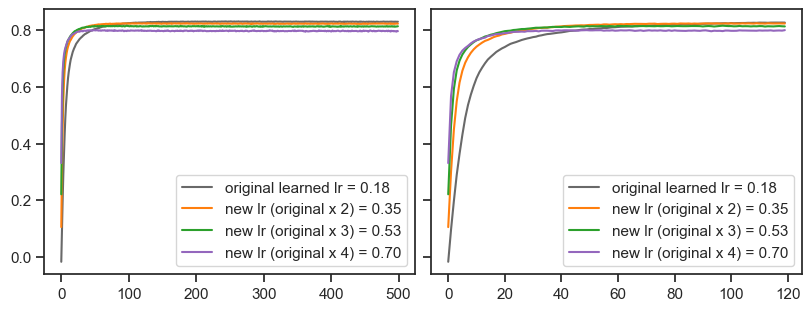

In [33]:
fig, axes = create_figure(1, 2, (8, 3), sharey='all')

for ax, num_t in zip(axes, [500, 120]):
    ax.plot(results['r2'][:num_t], color='dimgrey', label=f"original learned lr = {original_lr:0.2f}")
    ax.plot(results_2x['r2'][:num_t], color='C1', label=f"new lr (original x 2) = {original_lr * 2:0.2f}")
    ax.plot(results_3x['r2'][:num_t], color='C2', label=f"new lr (original x 3) = {original_lr * 3:0.2f}")
    ax.plot(results_4x['r2'][:num_t], color='C4', label=f"new lr (original x 4) = {original_lr * 4:0.2f}")
add_legend(axes)
plt.show()

In [34]:
def find_convergence(x, window=20, tol=1e-4, consecutive=5):
    x = np.asarray(x)
    slopes = []
    t_axis = np.arange(window)
    denom = np.var(t_axis) * window
    for i in range(len(x) - window + 1):
        y = x[i:i + window]
        cov = np.cov(t_axis, y, bias=True)[0, 1]
        slopes.append(cov / denom)
    slopes = np.abs(np.array(slopes))

    below = slopes < tol
    runlen = np.convolve(below, np.ones(consecutive, dtype=int), mode='valid')
    idx = np.where(runlen == consecutive)[0]
    if idx.size:
        return int(idx[0] + window)
    return len(x) - 1

In [38]:
kws_convergence = dict(
    tol=1e-5,
    window=30,
    consecutive=10,
)

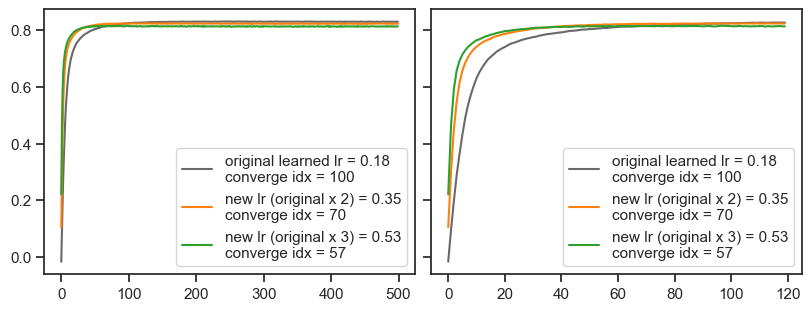

In [42]:
fig, axes = create_figure(1, 2, (8, 3), sharey='all')

for ax, num_t in zip(axes, [500, 120]):
    idx = find_convergence(results['r2'], **kws_convergence)
    ax.plot(results['r2'][:num_t], color='dimgrey', label=f"original learned lr = {original_lr:0.2f}\nconverge idx = {idx}")
    
    idx = find_convergence(results_2x['r2'], **kws_convergence)
    ax.plot(results_2x['r2'][:num_t], color='C1', label=f"new lr (original x 2) = {original_lr * 2:0.2f}\nconverge idx = {idx}")
    
    idx = find_convergence(results_3x['r2'], **kws_convergence)
    ax.plot(results_3x['r2'][:num_t], color='C2', label=f"new lr (original x 3) = {original_lr * 3:0.2f}\nconverge idx = {idx}")

add_legend(axes)
plt.show()

In [46]:
phi = tonp(tr.model.layer.get_weight())
w = phi.T @ phi
w.shape

(512, 512)

In [48]:
uu, ss, vh = sp_lin.svd(w, full_matrices=False)

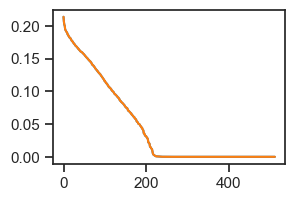

In [52]:
plt.plot(ss)
plt.show()

In [55]:
ss[:20]

array([0.21376298, 0.205877  , 0.20168857, 0.199867  , 0.19449411,
       0.19322537, 0.1920878 , 0.19088027, 0.19019128, 0.18898663,
       0.1866531 , 0.1863321 , 0.18461238, 0.1840134 , 0.18247806,
       0.1819252 , 0.18166788, 0.18069878, 0.1793996 , 0.17787303],
      dtype=float32)